In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

In [3]:
N_particles = 500

mpl.rcParams.update({
    # Font (gnuplot ≈ Helvetica)
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],

    # Dimensioni testo
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 9,

    # Linee
    "lines.linewidth": 1.8,

    # Assi
    "axes.linewidth": 1.0,

    # Griglia (stile gnuplot)
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,

    # Legenda
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "black",
    "legend.facecolor": "white"
})

In [4]:
def pot_neg(x,lamb):
    return np.pow(x,-12) - np.pow(x,-6) - lamb/x

def pot_pos(x,lamb):
    return np.pow(x,-12) - np.pow(x,-6) + lamb/x


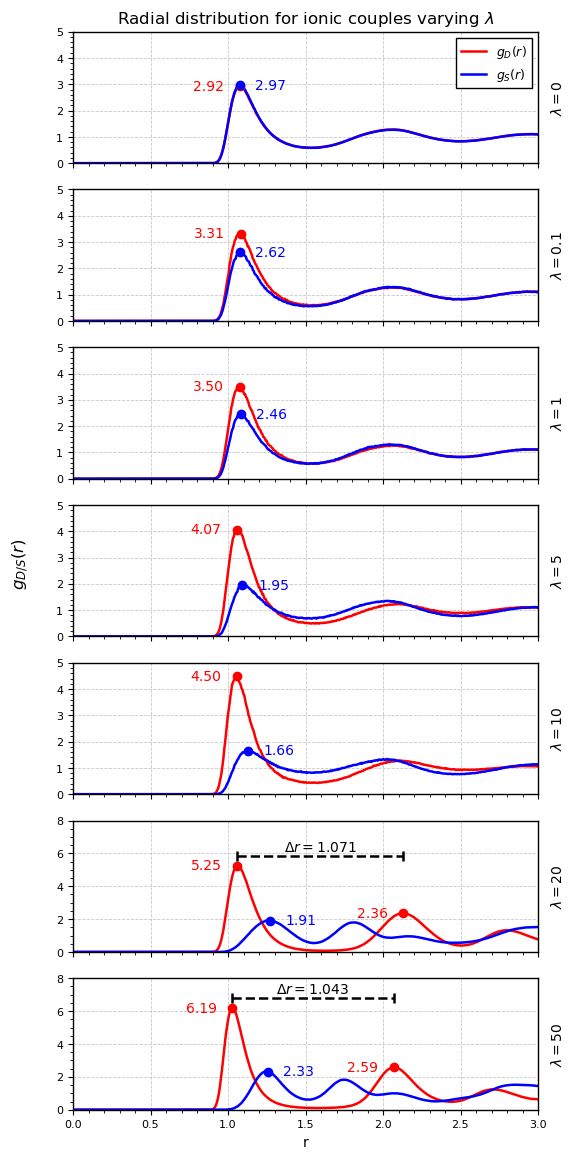

In [5]:
max_r_differ_array = []
max_g_differ_array = []

max_r_same_array = []
max_g_same_array = []

# 40%, 43%, 43%, 0.42%, 0.41%, 66%, 48%
lamb = [0, 0.1, 1,5,10,20,50]
n_lamb = np.size(lamb)

x = np.linspace(0.1,4,10000)

fig, axes = plt.subplots(n_lamb, 1, figsize=(6, 2*n_lamb),sharex=True)
fig.subplots_adjust(hspace=0.2) 

axes[0].set_title(r'Radial distribution for ionic couples varying $\lambda$')

for i in range(0,n_lamb):
    l = lamb[i]
    y = pot_neg(x,l)
    y_2 = pot_pos(x,l)

    data_differ = np.loadtxt(f"./lambda{l}/radial_distribution_differ.csv", delimiter=";")
    axes[i].plot(data_differ[:,0], data_differ[:,1],c="red", label=r"$g_D(r)$")

    idx = np.argmax(data_differ[:, 1])
    row_max = data_differ[idx]

    x_max_diff = data_differ[idx, 0]
    y_max_diff = data_differ[idx, 1]
    max_r_differ_array.append(x_max_diff)
    max_g_differ_array.append(y_max_diff)

    data_same = np.loadtxt(f"./lambda{l}/radial_distribution_equal.csv", delimiter=";")
    axes[i].plot(data_same[:,0], data_same[:,1],c="blue", label =r"$g_S(r)$")

    idx = np.argmax(data_same[:, 1])
    row_max = data_same[idx]

    x_max_same = data_same[idx, 0]
    y_max_same = data_same[idx, 1]
    max_r_same_array.append(x_max_same)
    max_g_same_array.append(y_max_same)

    axes[i].text(
        x_max_diff - 0.3, y_max_diff,
        f'{y_max_diff:.2f}',
        va='center',
        ha='left',
        color="red"
    )
    axes[i].plot(x_max_diff, y_max_diff, "o",color="red")

    axes[i].text(
        x_max_same + 0.1, y_max_same,
        f'{y_max_same:.2f}',
        va='center',
        ha='left',
        color="blue"
    )
    axes[i].plot(x_max_same, y_max_same, "o",color="blue")

    axes[i].text(
        1.025, 0.5,
        rf'$\lambda = {l}$',
        transform=axes[i].transAxes,
        rotation=90,
        va='center',
        ha='left'
    )

    axes[i].set_xlim([0,3])
    axes[i].set_ylim([0,5])

    if i != n_lamb-1:
        axes[i].tick_params(axis='x', labelbottom=False)
    
    if i == n_lamb-1:
        axes[i].set_xlabel("r")

    if l >= 20 :
        axes[i].set_ylim([0,8])

        # For last two plot the second maximum
        idx = np.argmax(data_differ[176:, 1]) + 176
        row_max = data_differ[idx]

        x_max_diff2 = data_differ[idx, 0]
        y_max_diff2 = data_differ[idx, 1]

        axes[i].text(
            x_max_diff2 - 0.3, y_max_diff2,
            f'{y_max_diff2:.2f}',
            va='center',
            ha='left',
            color="red"
        )
        axes[i].plot(x_max_diff2, y_max_diff2, "o",color="red")

        delta_x = x_max_diff2 - x_max_diff
        
        y_line = max(y_max_diff, y_max_diff2) + 0.6

        axes[i].hlines(
            y=y_line,
            xmin=x_max_diff,
            xmax=x_max_diff2,
            colors='black',
            linestyles='--'
        )

        axes[i].text(
            (x_max_diff + x_max_diff2) / 2,
            y_line + 0.1,
            rf'$\Delta r = {delta_x:.3f}$',
            ha='center',
            va='bottom'
        )

        cap_height = 0.3
        axes[i].vlines(
            x=[x_max_diff, x_max_diff2],
            ymin=y_line - cap_height,
            ymax=y_line + cap_height,
            colors='black'
        )

    if l == 100:
        axes[i].set_ylim([0,10])

    if i == 0:
        axes[i].legend(loc='upper right')

    axes[i].xaxis.minorticks_on()
    axes[i].yaxis.minorticks_on()
    
    #axes[i].set_ylabel("g(r)")
    axes[i].grid()

fig.supylabel(r"$g_{D/S}(r)$") # ylabel in common
plt.show()


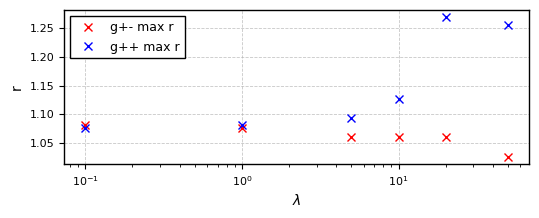

In [6]:
fig = plt.figure(figsize=(6,2))

plt.plot(lamb,max_r_differ_array,"x", label="g+- max r",c="red")
plt.plot(lamb,max_r_same_array, "x",label="g++ max r",c="blue")

plt.xscale("log")
plt.grid()
plt.xlabel(r"$\lambda$")
plt.ylabel("r")
plt.legend()
plt.show()

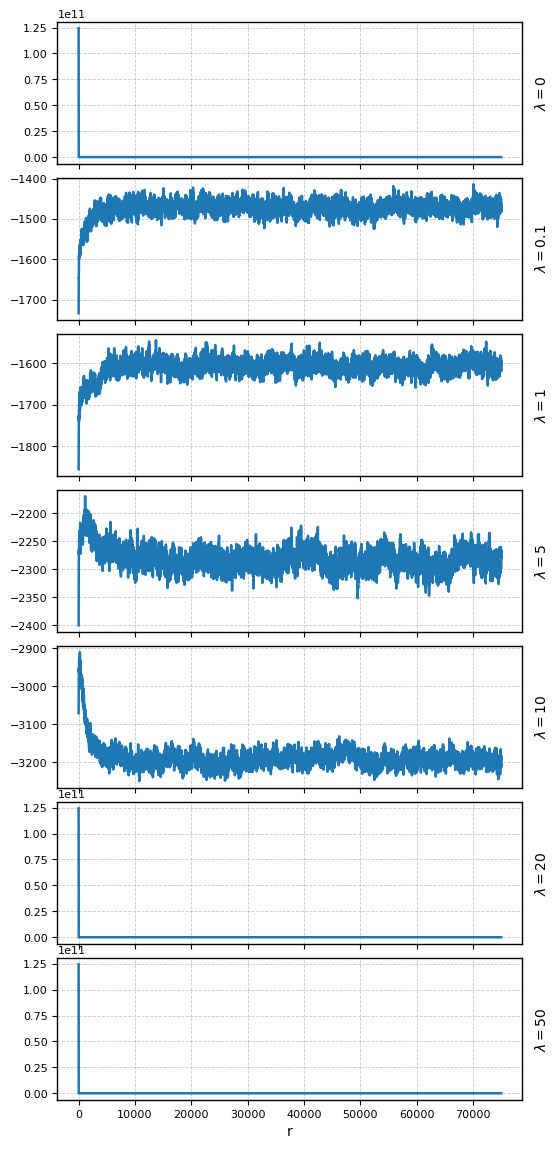

In [7]:
fig, axes = plt.subplots(n_lamb, 1, figsize=(6, 2*n_lamb))
fig.subplots_adjust(hspace=0.1) 

for i in range(0,n_lamb):
    l = lamb[i]
    
    data_en = np.loadtxt(f"./lambda{l}/energy.csv", delimiter=";")
    axes[i].plot(data_en)

    axes[i].text(
        1.025, 0.5,
        rf'$\lambda = {l}$',
        transform=axes[i].transAxes,
        rotation=90,
        va='center',
        ha='left'
    )
    
    if i != n_lamb-1:
        axes[i].tick_params(axis='x', labelbottom=False)
    
    if i == n_lamb-1:
        axes[i].set_xlabel("r")


    axes[i].grid()
    
plt.show()


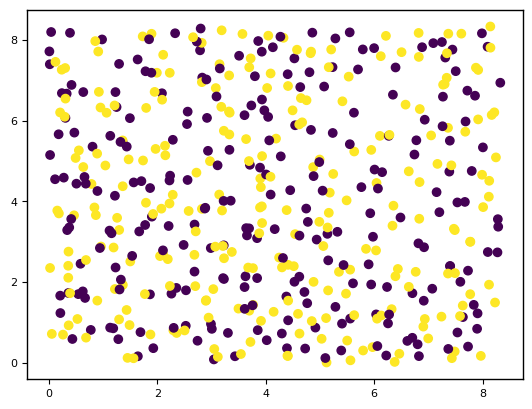

In [8]:
data = np.loadtxt(f"./lambda100/end_position_file.csv", delimiter=";")

plt.scatter(data[:,0], data[:,1],c=data[:,3])
plt.show()

Text(0.5, 1.0, 'Same and Different charges coupling potential energy')

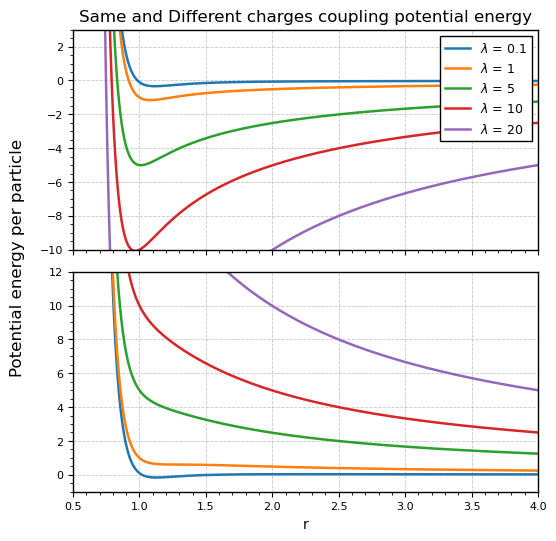

In [9]:

x = np.linspace(0.1,4,10000)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
fig.subplots_adjust(hspace=0.1) 

for l in lamb[1:-1]:
    y_1 = pot_neg(x,l)
    axes[0].plot(x,y_1,label=fr"$\lambda$ = {l}")

axes[0].legend()
axes[0].set_ylim([-10,3])
axes[0].set_xlim([0.5,4])
axes[0].tick_params(axis='x', labelbottom=False)
axes[0].legend(loc='upper right')

for l in lamb[1:-1]:
    y_2 = pot_pos(x,l)
    axes[1].plot(x,y_2)

axes[1].set_ylim([-1,12])
axes[1].set_xlim([0.5,4])

axes[1].grid()
axes[0].grid()

fig.supylabel(r"Potential energy per particle") # ylabel in common

axes[1].set_xlabel("r")

axes[0].xaxis.minorticks_on()
axes[0].yaxis.minorticks_on()

axes[1].xaxis.minorticks_on()
axes[1].yaxis.minorticks_on()
axes[0].set_title("Same and Different charges coupling potential energy")